In [42]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_rg3
from common.train_test_split import split_data
from common.model_composition import model_composition

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
rg3 = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3_다시되돌림.csv")

| 제품 | 시스템 처리 | 표시 내용 |
|---|---|---|
| RH | 공정값으로 위험도 산출·검사 우선순위 결정 | 위험 점수와 우선검사 여부 |
| LH | 자동 정상·불량 판정 보류 | **“LH 불량 학습 사례가 없어 AI 판정 대상에서 제외됩니다. 기존 품질검사를 진행하세요.”** |

In [44]:
rg3.shape

(1182, 29)

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

SEED = 42
TARGET_RECALL = 1.00
TEST_START = pd.Timestamp("2020-10-23")

In [46]:
# 컬럼 확인
rg3.columns.tolist()

['original_index',
 'PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4',
 'TimeStamp',
 'PART_NAME',
 'RH_LH']

In [47]:
# Target 분포
rg3["PassOrFail"].value_counts()

PassOrFail
0    1157
1      25
Name: count, dtype: int64

In [48]:
# RH / LH별 정상·불량 확인
pd.crosstab(
    rg3["RH_LH"],
    rg3["PassOrFail"],
    margins=True
)

PassOrFail,0,1,All
RH_LH,,,
LH,591,0,591
RH,566,25,591
All,1157,25,1182


2. 기본 전처리

In [49]:
# 날짜형 변환
rg3["TimeStamp"] = pd.to_datetime(rg3["TimeStamp"])

# 문자열 공백 제거
rg3["RH_LH"] = rg3["RH_LH"].astype("string").str.strip()
rg3["PART_NAME"] = rg3["PART_NAME"].astype("string").str.strip()

# 시간순 정렬
rg3 = rg3.sort_values(
    ["TimeStamp", "original_index"]
).reset_index(drop=True)

rg3[["TimeStamp", "PART_NAME", "RH_LH", "PassOrFail"]].head()

,TimeStamp,PART_NAME,RH_LH,PassOrFail
0,2020-10-21 00:16:26,"RG3 MOLD'G W/SHLD, LH",LH,0
1,2020-10-21 00:16:26,"RG3 MOLD'G W/SHLD, RH",RH,0
2,2020-10-21 00:17:26,"RG3 MOLD'G W/SHLD, RH",RH,0
3,2020-10-21 00:17:26,"RG3 MOLD'G W/SHLD, LH",LH,0
4,2020-10-21 00:18:29,"RG3 MOLD'G W/SHLD, RH",RH,0


In [50]:
# 공정 변수
SENSOR_COLUMNS = [
    "Injection_Time",
    "Filling_Time",
    "Plasticizing_Time",
    "Cycle_Time",
    "Clamp_Close_Time",
    "Cushion_Position",
    "Plasticizing_Position",
    "Clamp_Open_Position",
    "Max_Injection_Speed",
    "Max_Screw_RPM",
    "Average_Screw_RPM",
    "Max_Injection_Pressure",
    "Max_Switch_Over_Pressure",
    "Max_Back_Pressure",
    "Average_Back_Pressure",
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6",
    "Hopper_Temperature",
    "Mold_Temperature_3",
    "Mold_Temperature_4"
]

len(SENSOR_COLUMNS)

24

In [51]:
# 결측치 / 고유값 확인
column_check = pd.DataFrame({
    "dtype": rg3[SENSOR_COLUMNS].dtypes,
    "N_Unique": rg3[SENSOR_COLUMNS].nunique(),
    "Missing": rg3[SENSOR_COLUMNS].isna().sum()
})

column_check

,dtype,N_Unique,Missing
Injection_Time,float64,3,0
Filling_Time,float64,2,0
Plasticizing_Time,float64,27,0
Cycle_Time,float64,10,0
Clamp_Close_Time,float64,3,0
Cushion_Position,float64,7,0
Plasticizing_Position,float64,8,0
Clamp_Open_Position,float64,1,0
Max_Injection_Speed,float64,7,0
Max_Screw_RPM,float64,4,0


In [52]:
# 상수 컬럼 확인
constant_cols = [
    col for col in SENSOR_COLUMNS
    if rg3[col].nunique(dropna=False) <= 1
]

constant_cols

['Clamp_Open_Position']

In [53]:
# 기존 분석 기준 그대로 제외
EXCLUDED_COLS = [
    "Clamp_Open_Position",
    "Average_Screw_RPM"
]

FEATURE_COLS = [
    col for col in SENSOR_COLUMNS
    if col not in EXCLUDED_COLS
]

print("사용 변수 수:", len(FEATURE_COLS))
FEATURE_COLS

사용 변수 수: 22


['Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

# 3. RH만 모델링

In [54]:
# RG3 불량은 RH에서만 발생
rg3_rh = (
    rg3[rg3["RH_LH"] == "RH"]
    .copy()
    .reset_index(drop=True)
)

print("RH 전체 :", len(rg3_rh))
print("RH 정상 :", (rg3_rh["PassOrFail"] == 0).sum())
print("RH 불량 :", (rg3_rh["PassOrFail"] == 1).sum())

RH 전체 : 591
RH 정상 : 566
RH 불량 : 25


In [55]:
# 날짜별 불량 분포
pd.crosstab(
    rg3_rh["TimeStamp"].dt.date,
    rg3_rh["PassOrFail"]
)

PassOrFail,0,1
TimeStamp,,
2020-10-21,41,0
2020-10-22,285,15
2020-10-23,240,10


# 4. 개발 데이터 / holdout 분리

In [56]:
# 10월 21~22일 : 개발
# 10월 23일    : 최종 Holdout

train_rg3 = (
    rg3_rh[rg3_rh["TimeStamp"] < TEST_START]
    .copy()
    .reset_index(drop=True)
)

test_rg3 = (
    rg3_rh[rg3_rh["TimeStamp"] >= TEST_START]
    .copy()
    .reset_index(drop=True)
)

print("Train:", train_rg3.shape)
print("Test :", test_rg3.shape)

Train: (341, 29)
Test : (250, 29)


In [57]:
print("[Train Target]")
print(train_rg3["PassOrFail"].value_counts())

print("\n[Test Target]")
print(test_rg3["PassOrFail"].value_counts())

[Train Target]
PassOrFail
0    326
1     15
Name: count, dtype: int64

[Test Target]
PassOrFail
0    240
1     10
Name: count, dtype: int64


In [58]:
X_train = train_rg3[FEATURE_COLS]
y_train = train_rg3["PassOrFail"].astype(int)

X_test = test_rg3[FEATURE_COLS]
y_test = test_rg3["PassOrFail"].astype(int)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(341, 22) (341,)
(250, 22) (250,)


# 5. 교차검증 Fold

In [59]:
# 같은 생산 시점이 train / valid에 동시에 들어가지 않도록 그룹 지정
groups = train_rg3["TimeStamp"].dt.strftime(
    "%Y-%m-%d %H:%M:%S"
)

cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

folds = list(
    cv.split(
        X_train,
        y_train,
        groups=groups
    )
)

In [60]:
# Fold별 데이터 확인
for fold, (train_idx, valid_idx) in enumerate(folds, 1):
    print(
        f"Fold {fold} | "
        f"Train {len(train_idx)} / 불량 {y_train.iloc[train_idx].sum()} | "
        f"Valid {len(valid_idx)} / 불량 {y_train.iloc[valid_idx].sum()}"
    )

Fold 1 | Train 227 / 불량 10 | Valid 114 / 불량 5
Fold 2 | Train 228 / 불량 10 | Valid 113 / 불량 5
Fold 3 | Train 227 / 불량 10 | Valid 114 / 불량 5


# 6. 모델 후보

In [61]:
# Logistic Regression 6개
models = {}

weights = {
    "none": None,
    "w5": {0: 1, 1: 5},
    "balanced": "balanced"
}

for C in [0.1, 1.0]:
    for weight_name, weight in weights.items():

        model_name = f"LR_C{C}_{weight_name}"

        models[model_name] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("constant", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=C,
                class_weight=weight,
                solver="liblinear",
                max_iter=3000,
                random_state=SEED
            ))
        ])

len(models)

6

In [62]:
# Random Forest 4개
for depth in [2, 3]:
    for weight_name in ["none", "balanced"]:

        model_name = f"RF_d{depth}_{weight_name}"

        models[model_name] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("constant", VarianceThreshold()),
            ("model", RandomForestClassifier(
                n_estimators=200,
                max_depth=depth,
                min_samples_leaf=15,
                max_features="sqrt",
                class_weight=weights[weight_name],
                random_state=SEED,
                n_jobs=-1
            ))
        ])

print("비교 모델 수:", len(models))
models.keys()

비교 모델 수: 10


dict_keys(['LR_C0.1_none', 'LR_C0.1_w5', 'LR_C0.1_balanced', 'LR_C1.0_none', 'LR_C1.0_w5', 'LR_C1.0_balanced', 'RF_d2_none', 'RF_d2_balanced', 'RF_d3_none', 'RF_d3_balanced'])

# 7. 개발 데이터에서 모델 비교

In [63]:
cv_result = []
oof_scores = {}

for model_name, model in models.items():

    oof = np.zeros(len(X_train))

    for fold, (train_idx, valid_idx) in enumerate(folds, 1):

        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        X_val = X_train.iloc[valid_idx]
        y_val = y_train.iloc[valid_idx]

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        val_score = fold_model.predict_proba(X_val)[:, 1]
        oof[valid_idx] = val_score

        fold_ap = average_precision_score(
            y_val,
            val_score
        )

        cv_result.append({
            "Model": model_name,
            "Fold": fold,
            "PR_AUC": fold_ap
        })

    oof_scores[model_name] = oof

In [64]:
cv_result = pd.DataFrame(cv_result)

cv_result.head()

,Model,Fold,PR_AUC
0,LR_C0.1_none,1,0.080173
1,LR_C0.1_none,2,0.085570
2,LR_C0.1_none,3,0.079249
3,LR_C0.1_w5,1,0.068902
4,LR_C0.1_w5,2,0.089605


In [65]:
model_score = (
    cv_result
    .groupby("Model")["PR_AUC"]
    .agg(
        Mean_PR="mean",
        Std_PR="std",
        Min_PR="min",
        Max_PR="max"
    )
    .sort_values("Mean_PR", ascending=False)
)

model_score

,Mean_PR,Std_PR,Min_PR,Max_PR
Model,,,,
LR_C1.0_balanced,0.085714,0.020466,0.062082,0.097669
LR_C0.1_w5,0.084720,0.014028,0.068902,0.095653
LR_C0.1_balanced,0.083858,0.011137,0.074123,0.096003
LR_C1.0_w5,0.083105,0.022312,0.057352,0.096614
LR_C1.0_none,0.081729,0.021104,0.057464,0.095808
LR_C0.1_none,0.081664,0.003414,0.079249,0.085570
RF_d3_balanced,0.081150,0.032585,0.055158,0.117707
RF_d2_balanced,0.080144,0.029607,0.058242,0.113828
RF_d2_none,0.064085,0.022887,0.038784,0.083347


In [66]:
# 평균 PR-AUC가 가장 높은 모델 선택
BEST_MODEL_NAME = model_score.index[0]

best_model = models[BEST_MODEL_NAME]
best_oof = oof_scores[BEST_MODEL_NAME]

print("Best Model :", BEST_MODEL_NAME)
print("OOF PR-AUC :", average_precision_score(y_train, best_oof))

Best Model : LR_C1.0_balanced
OOF PR-AUC : 0.059512783165791575


# 8. Threshold 선택

In [67]:
threshold_result = []

for threshold in np.sort(np.unique(best_oof)):

    pred = (best_oof >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred,
        labels=[0, 1]
    ).ravel()

    threshold_result.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_train, pred, zero_division=0
        ),
        "F1": f1_score(
            y_train, pred, zero_division=0
        ),
        "Inspection_Rate": pred.mean(),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_result = pd.DataFrame(threshold_result)

threshold_result.head()

,Threshold,Precision,Recall,F1,Inspection_Rate,TP,FP,FN,TN
0,0.000427,0.043988,1.0,0.084270,1.000000,15,326,0,0
1,0.000483,0.044118,1.0,0.084507,0.997067,15,325,0,1
2,0.000738,0.044248,1.0,0.084746,0.994135,15,324,0,2
3,0.000821,0.044379,1.0,0.084986,0.991202,15,323,0,3
4,0.001263,0.044510,1.0,0.085227,0.988270,15,322,0,4


In [68]:
# Recall 0.80 이상 중 검사량이 가장 적은 threshold
threshold_candidate = (
    threshold_result[
        threshold_result["Recall"] >= TARGET_RECALL
    ]
    .sort_values(
        ["Inspection_Rate", "Threshold"],
        ascending=[True, False]
    )
)

threshold_candidate.head(10)

,Threshold,Precision,Recall,F1,Inspection_Rate,TP,FP,FN,TN
16,0.006815,0.046154,1.0,0.088235,0.953079,15,310,0,16
15,0.006618,0.046012,1.0,0.087977,0.956012,15,311,0,15
14,0.005933,0.045872,1.0,0.087719,0.958944,15,312,0,14
13,0.005768,0.045732,1.0,0.087464,0.961877,15,313,0,13
12,0.005405,0.045593,1.0,0.087209,0.964809,15,314,0,12
11,0.003442,0.045455,1.0,0.086957,0.967742,15,315,0,11
10,0.002479,0.045317,1.0,0.086705,0.970674,15,316,0,10
9,0.002403,0.045181,1.0,0.086455,0.973607,15,317,0,9
8,0.001858,0.045045,1.0,0.086207,0.976540,15,318,0,8
7,0.001698,0.044910,1.0,0.085960,0.979472,15,319,0,7


In [69]:
BEST_THRESHOLD = threshold_candidate.iloc[0]["Threshold"]

print("Best Threshold:", BEST_THRESHOLD)

threshold_candidate.head(1)

Best Threshold: 0.006815036192444283


,Threshold,Precision,Recall,F1,Inspection_Rate,TP,FP,FN,TN
16,0.006815,0.046154,1.0,0.088235,0.953079,15,310,0,16


# 9. 개발 구간 시간 순서 점검

In [70]:
# 10월 22일 04시 기준으로 과거 -> 미래 확인
early_mask = (
    train_rg3["TimeStamp"]
    < pd.Timestamp("2020-10-22 04:00:00")
)

print("Early :", early_mask.sum())
print("Later :", (~early_mask).sum())

print("Early Defect :", y_train[early_mask].sum())
print("Later Defect :", y_train[~early_mask].sum())

Early : 144
Later : 197
Early Defect : 5
Later Defect : 10


In [71]:
temporal_model = clone(best_model)

temporal_model.fit(
    X_train.loc[early_mask],
    y_train.loc[early_mask]
)

temporal_score = temporal_model.predict_proba(
    X_train.loc[~early_mask]
)[:, 1]

temporal_pred = (
    temporal_score >= BEST_THRESHOLD
).astype(int)

In [72]:
temporal_cm = confusion_matrix(
    y_train.loc[~early_mask],
    temporal_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = temporal_cm.ravel()

temporal_result = pd.DataFrame([{
    "PR_AUC": average_precision_score(
        y_train.loc[~early_mask],
        temporal_score
    ),
    "Precision": precision_score(
        y_train.loc[~early_mask],
        temporal_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_train.loc[~early_mask],
        temporal_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_train.loc[~early_mask],
        temporal_pred,
        zero_division=0
    ),
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "TN": tn
}])

temporal_result

,PR_AUC,Precision,Recall,F1,TP,FP,FN,TN
0,0.035793,0.032967,0.6,0.0625,6,176,4,11


# 최종 모델 학습

In [73]:
final_model = clone(best_model)

final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('constant', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Injection_Time','Filling_Time','Plasticizing_Time',..., 'Hopper_Temperature','Mold_Temperature_3','Mold_Temperature_4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace a

# 11. 10월 23일 Holdout 평가

In [74]:
test_score = final_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_score >= BEST_THRESHOLD
).astype(int)

In [75]:
test_cm = confusion_matrix(
    y_test,
    test_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = test_cm.ravel()

test_metrics = pd.DataFrame([{
    "PR_AUC": average_precision_score(
        y_test,
        test_score
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_score
    ),
    "Precision": precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "TN": tn
}])

test_metrics

,PR_AUC,ROC_AUC,Precision,Recall,F1,TP,FP,FN,TN
0,0.037305,0.38875,0.04,1.0,0.076923,10,240,0,0


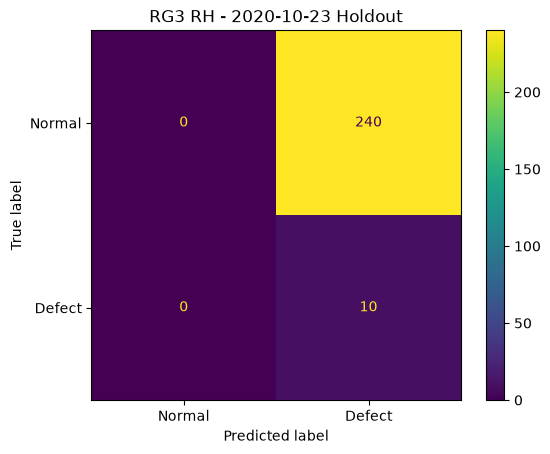

In [76]:
ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["Normal", "Defect"]
).plot()

plt.title("RG3 RH - 2020-10-23 Holdout")
plt.show()

# 12. 검사량별 불량 포착

In [77]:
ranked = test_rg3[
    ["original_index", "TimeStamp", "PassOrFail"]
].copy()

ranked["Risk_Score"] = test_score

ranked = ranked.sort_values(
    ["Risk_Score", "TimeStamp", "original_index"],
    ascending=[False, True, True]
).reset_index(drop=True)

ranked.head()

,original_index,TimeStamp,PassOrFail,Risk_Score
0,2367,2020-10-23 07:33:43,0,0.999953
1,2208,2020-10-23 06:11:21,0,0.999906
2,2018,2020-10-23 02:23:51,0,0.999792
3,2252,2020-10-23 06:34:01,0,0.999692
4,2366,2020-10-23 07:32:40,0,0.999603


In [78]:
total_defect = int(
    ranked["PassOrFail"].sum()
)

inspection_result = []

for rate in [0.10, 0.20, 0.30, 0.50, 1.00]:

    inspect_n = int(
        np.ceil(len(ranked) * rate)
    )

    selected = ranked.head(inspect_n)

    caught = int(
        selected["PassOrFail"].sum()
    )

    inspection_result.append({
        "Inspection_Rate": rate,
        "Inspect_N": inspect_n,
        "Defect_Caught": caught,
        "Defect_Missed": total_defect - caught,
        "Recall": caught / total_defect,
        "Precision": caught / inspect_n,
        "Random_Expected_Recall": inspect_n / len(ranked)
    })

inspection_result = pd.DataFrame(
    inspection_result
)

inspection_result

,Inspection_Rate,Inspect_N,Defect_Caught,Defect_Missed,Recall,Precision,Random_Expected_Recall
0,0.1,25,1,9,0.1,0.040000,0.1
1,0.2,50,1,9,0.1,0.020000,0.2
2,0.3,75,2,8,0.2,0.026667,0.3
3,0.5,125,4,6,0.4,0.032000,0.5
4,1.0,250,10,0,1.0,0.040000,1.0


# 13. 실제 불량 / 오탐 확인

In [79]:
test_result = test_rg3[
    [
        "original_index",
        "TimeStamp",
        "PART_NAME",
        "RH_LH",
        "PassOrFail"
    ]
].copy()

test_result["Risk_Score"] = test_score
test_result["Pred"] = test_pred

test_result.head()

,original_index,TimeStamp,PART_NAME,RH_LH,PassOrFail,Risk_Score,Pred
0,1893,2020-10-23 01:01:28,"RG3 MOLD'G W/SHLD, RH",RH,0,0.857892,1
1,1896,2020-10-23 01:02:30,"RG3 MOLD'G W/SHLD, RH",RH,0,0.311204,1
2,1897,2020-10-23 01:03:33,"RG3 MOLD'G W/SHLD, RH",RH,1,0.391188,1
3,1899,2020-10-23 01:04:35,"RG3 MOLD'G W/SHLD, RH",RH,0,0.499527,1
4,1902,2020-10-23 01:05:36,"RG3 MOLD'G W/SHLD, RH",RH,0,0.145418,1


In [80]:
# 실제 불량
test_result[
    test_result["PassOrFail"] == 1
].sort_values(
    "Risk_Score",
    ascending=False
)

,original_index,TimeStamp,PART_NAME,RH_LH,PassOrFail,Risk_Score,Pred
219,2331,2020-10-23 07:15:11,"RG3 MOLD'G W/SHLD, RH",RH,1,0.993850,1
145,2183,2020-10-23 05:59:00,"RG3 MOLD'G W/SHLD, RH",RH,1,0.974164,1
142,2177,2020-10-23 05:54:52,"RG3 MOLD'G W/SHLD, RH",RH,1,0.966323,1
135,2163,2020-10-23 05:47:40,"RG3 MOLD'G W/SHLD, RH",RH,1,0.965885,1
225,2343,2020-10-23 07:21:20,"RG3 MOLD'G W/SHLD, RH",RH,1,0.885582,1
106,2105,2020-10-23 05:15:46,"RG3 MOLD'G W/SHLD, RH",RH,1,0.870153,1
22,1937,2020-10-23 01:24:09,"RG3 MOLD'G W/SHLD, RH",RH,1,0.455781,1
2,1897,2020-10-23 01:03:33,"RG3 MOLD'G W/SHLD, RH",RH,1,0.391188,1
40,1973,2020-10-23 02:01:11,"RG3 MOLD'G W/SHLD, RH",RH,1,0.291927,1
64,2021,2020-10-23 02:25:54,"RG3 MOLD'G W/SHLD, RH",RH,1,0.265301,1


In [81]:
# 놓친 불량
missed_defect = test_result[
    (test_result["PassOrFail"] == 1) &
    (test_result["Pred"] == 0)
]

missed_defect

,original_index,TimeStamp,PART_NAME,RH_LH,PassOrFail,Risk_Score,Pred


In [82]:
# 정상인데 불량으로 예측한 오탐
false_positive = test_result[
    (test_result["PassOrFail"] == 0) &
    (test_result["Pred"] == 1)
]

false_positive

,original_index,TimeStamp,PART_NAME,RH_LH,PassOrFail,Risk_Score,Pred
0,1893,2020-10-23 01:01:28,"RG3 MOLD'G W/SHLD, RH",RH,0,0.857892,1
1,1896,2020-10-23 01:02:30,"RG3 MOLD'G W/SHLD, RH",RH,0,0.311204,1
3,1899,2020-10-23 01:04:35,"RG3 MOLD'G W/SHLD, RH",RH,0,0.499527,1
4,1902,2020-10-23 01:05:36,"RG3 MOLD'G W/SHLD, RH",RH,0,0.145418,1
5,1903,2020-10-23 01:06:38,"RG3 MOLD'G W/SHLD, RH",RH,0,0.452700,1
...,...,...,...,...,...,...,...
245,2384,2020-10-23 07:41:57,"RG3 MOLD'G W/SHLD, RH",RH,0,0.994617,1
246,2386,2020-10-23 07:42:58,"RG3 MOLD'G W/SHLD, RH",RH,0,0.904630,1
247,2387,2020-10-23 07:44:00,"RG3 MOLD'G W/SHLD, RH",RH,0,0.971606,1
248,2389,2020-10-23 07:45:02,"RG3 MOLD'G W/SHLD, RH",RH,0,0.934091,1


# 14. Baseline 성능 평가

| 항목 | 현재 결과 | 판단 |
|---|---:|---|
| Recall | **100%** | 좋음 |
| FN | **0** | 좋음 |
| Precision | 4.62% | 매우 낮음 |
| FP | 310 | 너무 많음 |
| 검사율 | **95.3%** | 거의 전수검사 |
| 불량률 대비 Precision | 4.40% → 4.62% | 개선 거의 없음 |